# Definitions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.special import gamma

import numba

from lattice import Graphene


from matplotlib.patches import Polygon


import matplotlib.pyplot as plt

import numpy as np
from scipy.special import gamma
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import bmat, diags, block_diag

import numba
from lattice import Graphene

from simulation import System, Eletric_field, Leg
from simulation import add_atom_to_hamiltonian, time_evolution

from utils import draw_basis_vectors, draw_electric_field, annotate_electric_field_text, separate_each_lattice, plot_graphene

/Users/marcel/Library/CloudStorage/OneDrive-UNIPA/Jupyter nb/graphene domain wall/simulation.py:170: SyntaxWarning: invalid escape sequence '\p'
  axs[1,i].set_xlabel("$k_x$ (units of $\pi$)")
/Users/marcel/Library/CloudStorage/OneDrive-UNIPA/Jupyter nb/graphene domain wall/simulation.py:171: SyntaxWarning: invalid escape sequence '\p'
  axs[1,i].set_ylabel("$k_y$ (units of $\pi$)")


In [3]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 20  


PATH = "./plots/"

In [4]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 30  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30 

In [5]:
@numba.njit(fastmath=True, error_model="numpy", parallel=True)
def compute_population(kx_values, ky_values, psi_bath, delta, n, nu = 1, sigma=1):
    K = nu * 4 * np.pi / (3 * np.sqrt(3.)) * np.array([1.,0], dtype=np.float64)
    V = 3/2

    # Prep the basis for phi_a and phi_b
    na = np.zeros_like(n[0], dtype=np.float64)
    nb = np.zeros_like(n[0], dtype=np.float64)

    N = len(n[0])

    Na = Nb = N // 2
    sqrtNa = Na ** 0.5
    sqrtNb = Nb ** 0.5

    sqrt2 = 2 ** 0.5
    na[:(N // 2)] = 1.
    nb[(N // 2):] = 1.

    pop = np.zeros((len(kx_values), len(ky_values)), dtype=np.float64)

    for i in numba.prange(len(ky_values)):
        ky = kx_values[i]
        qy = ky - K[1]
        for j in range(len(kx_values)):
            kx = ky_values[j]
            qx = kx - K[0]

            # computing phi_a and phi_b
            # exp_part = np.exp(1j * (K[0] * n[0] + K[1] * n[1]) + 1j * (qx * n[0] + qy * n[1]))

            exp_part = np.exp(1j * ((K[0] + qx) * n[0] + (K[1] + qy) * n[1]))
            # exp_part = np.exp(1j * (kx * n[0] + ky * n[1]))
            phi_a = exp_part * na / sqrtNa
            phi_b = exp_part * nb / sqrtNb

            # Computing now the total phi
            qx2_qy2 = qx ** 2 + qy ** 2
            omega = np.sqrt(delta ** 2 + (V ** 2) * qx2_qy2)
            theta = - nu * np.arctan2(qy, qx)
            coeff_a = np.sqrt(1. + sigma * delta / omega)
            coeff_b = sigma * np.sqrt(1 - sigma * delta / omega) * np.exp(-1j * theta)
            
            phi = (coeff_a * phi_a + coeff_b * phi_b) /sqrt2

            scalar_prod = 0. + 0.j
            for l in range(len(psi_bath)):
                scalar_prod += phi[l].conjugate() * psi_bath[l]

            pop[i,j] = np.abs(scalar_prod) ** 2

    return pop

def draw_FBZ(ax, edges, color="black", lw=1):
  points = np.array(edges)
  centroid = points.mean(axis=0)
  angles = np.arctan2(points[:, 1] - centroid[1],
                    points[:, 0] - centroid[0])
  ordered = points[np.argsort(angles)]
  polygon = Polygon(ordered, closed=True, fill=False, edgecolor=color , linestyle="--", lw=lw)
  ax.add_patch(polygon)


In [6]:
a = 1
b1 = (4 * np.pi)/(3 * a) * np.array([1, 0])
b2 = np.array([-(2 * np.pi/ (3 * a)), (2 * np.pi)/(np.sqrt(3) * a)])


K1 = (b1 - b2) / 3
K2 = -K1

K3 = K1 - b1
K4 = K2 + b1

K5 = K1 + b2 # Along y only
K6 = K2 - b2 # Along y only

KK = np.array([K1, K2, K3, K4, K5, K6])

# Figure 2

Each valley is a corner in the FBZ. 

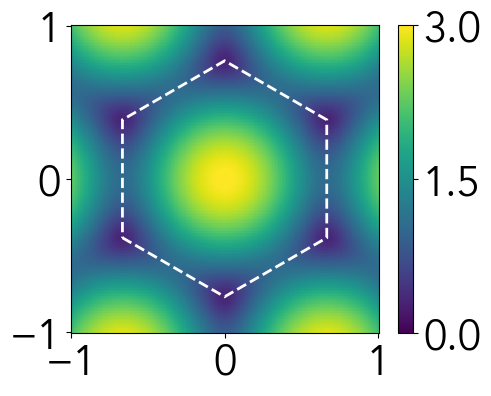

In [9]:
def energy(kx, ky, delta):
   return np.sqrt(delta ** 2 + 3 + 2 * np.cos(np.sqrt(3) * ky) + 4. * np.cos(np.sqrt(3.)* ky * 0.5) * np.cos(3. * kx *0.5))


delta = 0.3
kx = np.linspace(- np.pi, np.pi, 200)
ky = np.linspace(- np.pi, np.pi, 200)

Kx, Ky = np.meshgrid(kx, ky)

fig, ax = plt.subplots(figsize=(5,4))

im = ax.pcolormesh(Kx / np.pi, Ky / np.pi, energy(Kx, Ky, delta), rasterized=True, vmin=0, vmax=3)
fig.colorbar(im, ax=ax, ticks=[0, 1.5, 3])

draw_FBZ(ax, KK / np.pi, color="white", lw=2)
ax.set_aspect("equal")

plt.savefig(PATH + "spectrum_fbz.pdf", bbox_inches="tight")



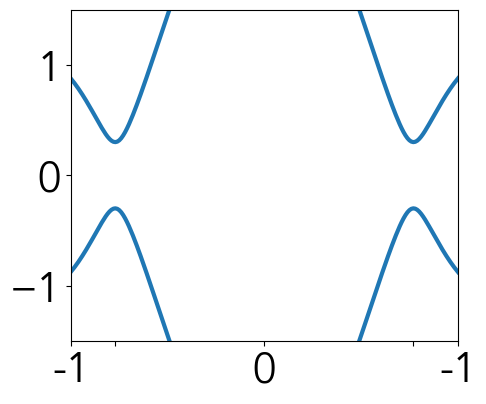

In [10]:
delta = 0.3

ky = np.linspace(- np.pi, np.pi, 200)

fig, ax = plt.subplots(figsize=(5,4.3))

ax.plot(kx /np.pi, energy(0, ky, delta), color="tab:blue", lw=3)
ax.plot(kx /np.pi, -energy(0, ky, delta), color="tab:blue", lw=3)
ax.set_ylim(-5 * delta, 5* delta) 
ax.set_xlim(-1., 1.)

xticks = [-1, K6[1]/np.pi, 0, K5[1]/np.pi, 1]

ax.set_xticks(xticks)
ax.set_xticklabels([-1, None, 0, None, -1])
plt.savefig(PATH + "plot_gap.pdf", bbox_inches="tight")
# plt.xlabel("$k_x$")
# plt.ylabel("$\\omega_{k}$")

# Figure 3

In [308]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 30  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30 

In [309]:
import matplotlib.pyplot as plt

import numpy as np
from scipy.special import gamma
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import bmat, diags, block_diag

import numba
from lattice import Graphene

from simulation import System, Eletric_field, Leg
from simulation import add_atom_to_hamiltonian, time_evolution

from utils import draw_basis_vectors, draw_electric_field, annotate_electric_field_text, separate_each_lattice

In [310]:

class Graphene2:

  def __init__(self, nmax, onsite_energy=(0,0), J = 1., a = 1, pbc=False, eletric_field_params=False, dissipation_strength=0.):
    self.nmax = nmax
    self.mid_point = np.array([nmax - 1, nmax-1], dtype=int) / 2
    self.la = self.lb = nmax ** 2
    self.onsite_energy = {"A": onsite_energy[0], "B": onsite_energy[1]}
    self.J = J
    self.a = 1.
    self.pbc = pbc

    self.a1 = np.sqrt(3)/2 * np.array([np.sqrt(3), 1.])
    self.a2 = np.sqrt(3) * np.array([0, 1.])
    self.d1 = -0.5 * np.array([1., np.sqrt(3)])

    self.eletric_field_params = eletric_field_params
    self.coord_map = self._create_coordinates_map(shape=(nmax, nmax))


  # def __str__(self):
  #   return "test"

  def _generate_block_Hamiltonian_pbc(self):
    # Generating the block diagonal matrix
    ks = [0, -1]

    diagonals = [np.full(self.nmax, - self.J) for k in ks]
    block = diags(diagonals, ks).todok()
    block[0,-1] = - self.J
    block_diagonal = block_diag([block] * self.nmax)


    ks = [self.la - self.nmax, - self.nmax]
    diagonals = [
        np.full(self.nmax, - self.J),
        np.full(self.la - self.nmax, - self.J)
    ]

    # Generating the other diagonal values of the matrix
    other_diagonal = diags(diagonals, ks, shape=(self.la, self.la))

    return block_diagonal + other_diagonal


  def _generate_block_Hamiltonian_non_pbc(self):
    ks = [0, 1, self.nmax]

    diagonals = [np.full(self.la, -self.J) for k in ks]
    diagonals[1][self.nmax - 1 :: self.nmax] = 0.

    return diags(diagonals, ks)


  def num_sites(self, kind="all"):
    match kind.upper():
      case "A":
        return self.la
      case "B":
        return self.lb
      case "ALL":
        return self.la + self.lb
      case _:
        return None


  def _compute_linear_potential(self, params):
    na, nb = self.n_real_pos
    n = np.vstack([na.T, nb.T]).T

    epsilon_0 = params.modulus
    theta = params.theta
    u = np.array([np.cos(theta), np.sin(theta)])

    self.U = - epsilon_0 * n.T @ u

  @property
  def hamiltonian(self):
    if self.pbc:
      Hab = self._generate_block_Hamiltonian_pbc().T
    else:
      Hab = self._generate_block_Hamiltonian_non_pbc()

    if self.eletric_field_params:
      self._compute_linear_potential(self.eletric_field_params)
      eletric_field = {
        "A": self.U[:self.la],
        "B": self.U[self.la:]
      }

      diagonal = {
          "A" : eletric_field["A"] + np.full(self.la, self.onsite_energy["A"]),
          "B" : eletric_field["B"] + np.full(self.lb, self.onsite_energy["B"])
      }
    else:
     diagonal = {
          "A" : np.full(self.la, self.onsite_energy["A"]),
          "B" : np.full(self.lb, self.onsite_energy["B"])
      }


    block = {
        "A": diags(diagonal["A"]),
        "B": diags(diagonal["B"])
    }

    return bmat([
        [block["A"], Hab],
        [Hab.T, block["B"]]
      ]).todok()


  @staticmethod
  def _create_coordinates_map(shape):
    x, y = shape
    total_size = x * y

    a = np.arange(total_size).reshape(shape)

    b = total_size + a

    avg_x = int(x / 2)
    avg_y = int(y / 2)

    return {
        "A": {(i - avg_x, j - avg_y) : a[j,i] for i in range(x) for j in range(y)},
        "B": {(i - avg_x, j - avg_y) : b[j,i] for i in range(x) for j in range(y)},
      }

  @property
  def n_real_pos(self):
    coord_map = self.coord_map
    inv_mapA = {value : key for key, value in coord_map['A'].items()}

    m = np.array([(nx, ny) for _, (nx,ny) in sorted(inv_mapA.items())])

    Ma = np.array([self.a1, self.a2]).T

    na = Ma @ m.T

    nb = na.copy()
    # assuming lattice constant a = 1
    nb[1] = nb[1] - self.a

    return na, nb

  @property
  def edge_points(self):
    x_max, y_max = max(self.coord_map["A"].keys())
    x_min, y_min = min(self.coord_map["A"].keys())

    return x_max, y_max, x_min, y_min


  @property
  def graph(self):
    adj_matrix = self.hamiltonian.todense() / (-self.J)

    return nx.from_numpy_array(adj_matrix)


  def _graphene_layout(self, a=1):
    a_positions = self.coord_map["A"].keys()
    b_positions = self.coord_map["B"].keys()

    a1 = self.a1
    a2 = self.a2

    delta = self.d1

    Ma = np.array([a1, a2]).T

    a_pos_plot = [Ma @ np.array([n1,n2]) for n1, n2 in a_positions]
    b_pos_plot = [(Ma @ np.array([n1,n2])) + delta for n1, n2 in b_positions]

    a_nodes_pos = {node: position for node, position in enumerate(a_pos_plot)}
    b_nodes_pos = {node: position for node, position in enumerate(b_pos_plot, start=self.la)}

    return a_nodes_pos | b_nodes_pos


  def plot(self, with_labels=False):
    G = self.graph

    node_size = 60
    fig, ax = plt.subplots(figsize=(15,9))

    pos = self._graphene_layout()

    a_nodes = range(self.la)
    b_nodes = range(self.la, self.la + self.lb)

    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_nodes(G, node_size=node_size, pos=pos, nodelist=a_nodes,ax=ax).set_edgecolor('black')
    nx.draw_networkx_nodes(G, node_size=node_size, node_color="darkorange", pos=pos, nodelist=b_nodes, ax=ax).set_edgecolor('black')

    offset = np.array([0.,0.2])

    labels_pos = {node: position + offset for node, position in pos.items()}

    if with_labels:
      nx.draw_networkx_labels(G, pos=labels_pos)

    plt.box(False)
    plt.show()

    return fig, ax

In [311]:
TMAX = 130
DELTA = 0.5
OMEGA_0 =0.7
G = 0.18
PHI = np.pi/3

NUM_POINTS = 50
NMAX = 331

sys = System(
            lattice=Graphene2(
                nmax=NMAX,
                onsite_energy=(DELTA,-DELTA),
                pbc=True,
                eletric_field_params=Eletric_field(modulus=0, direction="x")
            ),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              # Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

t = np.linspace(0, TMAX, NUM_POINTS)

H = add_atom_to_hamiltonian(sys)
psi = time_evolution(H,TMAX, full=True, num_points=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

nn_a, nn_b = sys.lattice.n_real_pos
n = np.hstack([nn_a, nn_b])

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

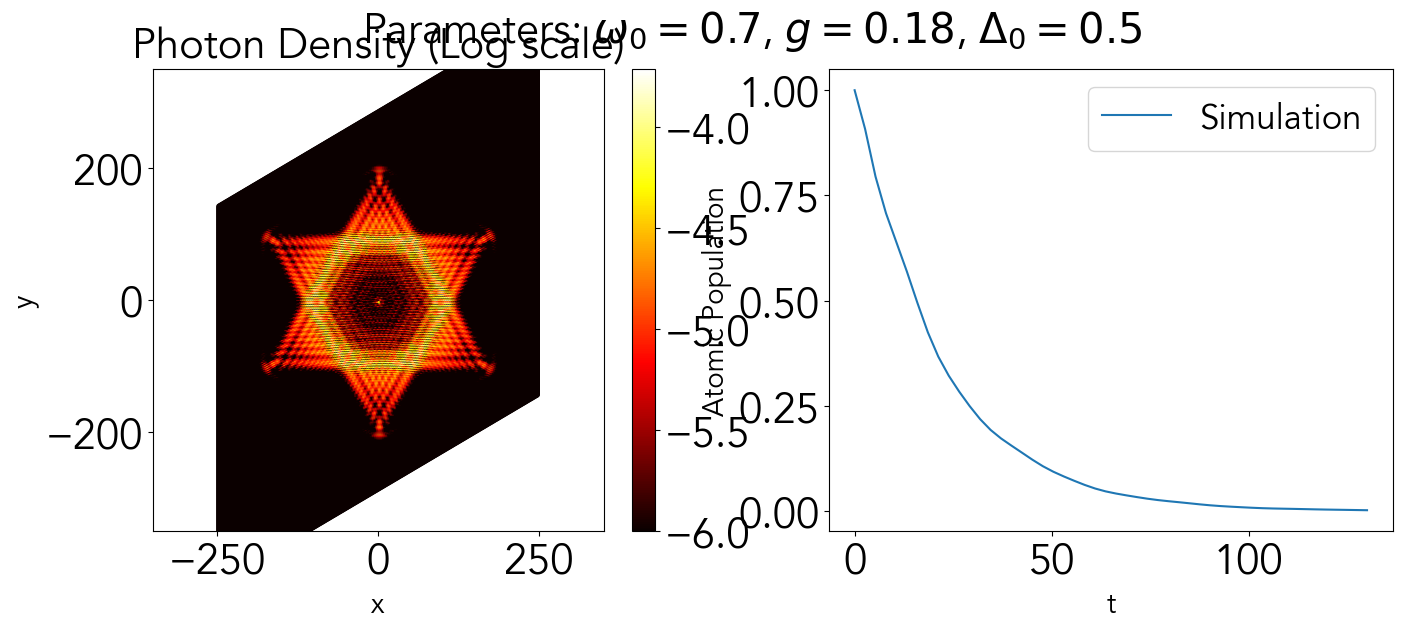

In [312]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6


na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = sys.lattice.a1
a2 = sys.lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])

axs[1].plot(t, pe, label="Simulation")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
# fig.savefig(PATH + "emission_giant_atom1.pdf", bbox_inches="tight")


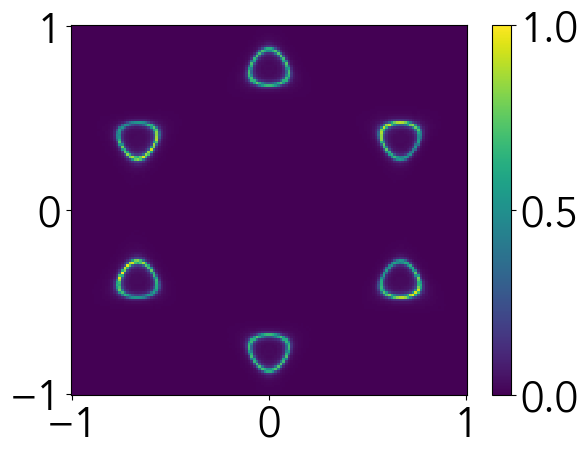

In [313]:
kx = ky = np.linspace(-np.pi, np.pi, 150)
population = sum(
    compute_population(kx, ky, psi_bath=psi_latt[-1], delta=DELTA, n=n, nu=nu) for nu in (-1,1)
)

im = plt.pcolormesh(kx/np.pi, ky/np.pi, population/population.max(), rasterized=True, vmin=0, vmax=1.)
cbar = plt.colorbar(im, ticks=[0., 0.5, 1.])
cbar.set_ticklabels([0., 0.5, 1.])

plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])

# plt.xlabel("$k_x$")
# plt.ylabel("$k_y$")

plt.savefig(PATH + "momentum_photon_density_normal_atom.pdf", bbox_inches="tight")

In [314]:
print(f"The last point in time is t={pe[-1]:.3f}")

The last point in time is t=0.002


In [315]:
TMAX = 130
DELTA = 0.5
OMEGA_0 =0.7
G = 0.18 / np.sqrt(2)
PHI = np.pi/3

NUM_POINTS = 50
NMAX = 331

sys = System(
            lattice=Graphene2(
                nmax=NMAX,
                onsite_energy=(DELTA,-DELTA),
                pbc=True,
                eletric_field_params=Eletric_field(modulus=0, direction="x")
            ),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

t = np.linspace(0, TMAX, NUM_POINTS)

H = add_atom_to_hamiltonian(sys)
psi = time_evolution(H,TMAX, full=True, num_points=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

nn_a, nn_b = sys.lattice.n_real_pos
n = np.hstack([nn_a, nn_b])

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe_giant = np.abs(psi_atom) ** 2

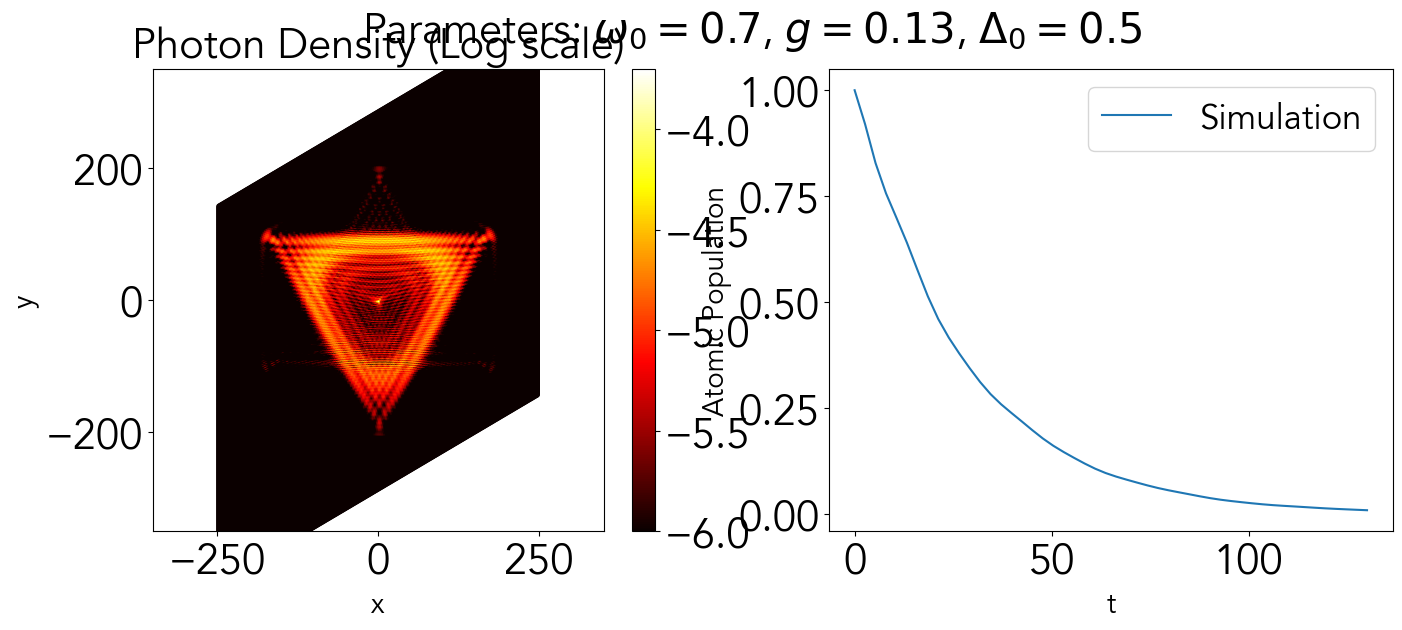

In [316]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = sys.lattice.a1
a2 = sys.lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])

axs[1].plot(t, pe_giant, label="Simulation")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G:.2f}$, $\\Delta_0 = {DELTA}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
# fig.savefig(PATH + "emission_giant_atom1.pdf", bbox_inches="tight")


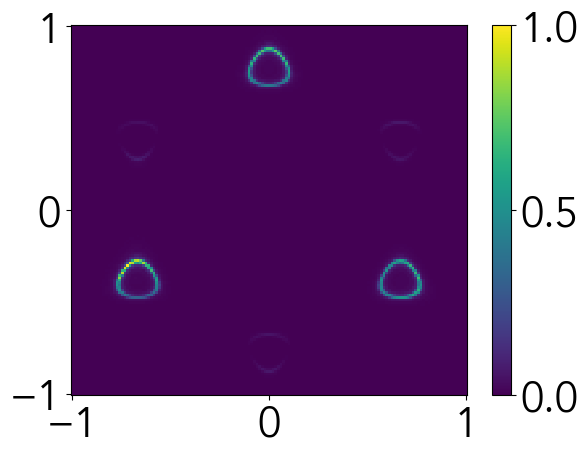

In [317]:
kx = ky = np.linspace(-np.pi, np.pi, 150)
population = sum(
    compute_population(kx, ky, psi_bath=psi_latt[-1], delta=DELTA, n=n, nu=nu) for nu in (-1,1)
)

im = plt.pcolormesh(kx/np.pi, ky/np.pi, population/population.max(), rasterized=True, vmin=0, vmax=1.)
cbar = plt.colorbar(im, ticks=[0., 0.5, 1.])
cbar.set_ticklabels([0., 0.5, 1.])

plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])


# plt.xlabel("$k_x$")
# plt.ylabel("$k_y$")

plt.savefig(PATH + "momentum_photon_density_giant_piO3.pdf", bbox_inches="tight")

In [318]:
print(f"The last point in time is t={pe_giant[-1]:.3f}")

The last point in time is t=0.009


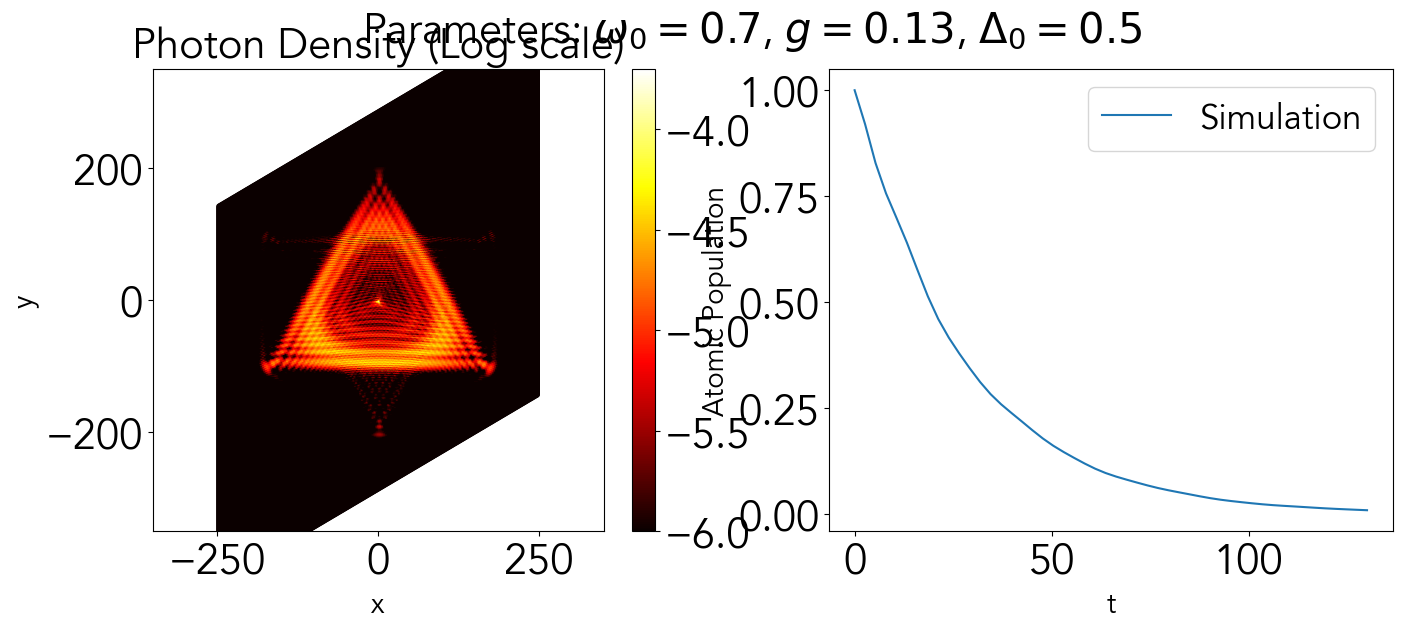

In [319]:
TMAX = 130
DELTA = 0.5
OMEGA_0 =0.7
G = 0.18 / np.sqrt(2)
PHI = -np.pi/3

NUM_POINTS = 50
NMAX = 331

sys = System(
            lattice=Graphene2(
                nmax=NMAX,
                onsite_energy=(DELTA,-DELTA),
                pbc=True,
                eletric_field_params=Eletric_field(modulus=0, direction="x")
            ),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

t = np.linspace(0, TMAX, NUM_POINTS)

H = add_atom_to_hamiltonian(sys)
psi = time_evolution(H,TMAX, full=True, num_points=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

nn_a, nn_b = sys.lattice.n_real_pos
n = np.hstack([nn_a, nn_b])

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe_giant2 = np.abs(psi_atom) ** 2

FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = sys.lattice.a1
a2 = sys.lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])

axs[1].plot(t, pe_giant2, label="Simulation")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G:.2f}$, $\\Delta_0 = {DELTA}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
# fig.savefig(PATH + "emission_giant_atom1.pdf", bbox_inches="tight")


In [320]:
print(f"The last point in time is t={pe_giant2[-1]:.3f}")

The last point in time is t=0.009


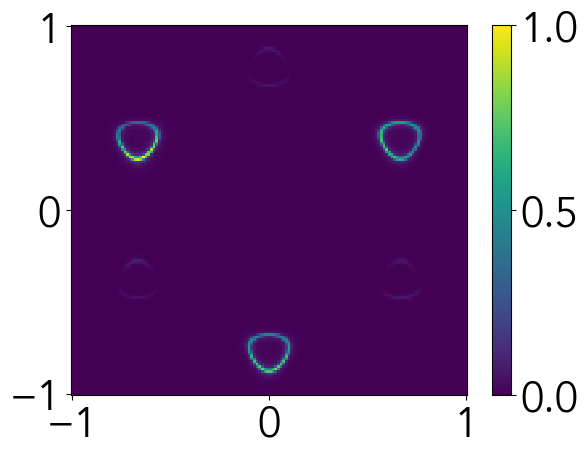

In [321]:
kx = ky = np.linspace(-np.pi, np.pi, 150)
population = sum(
    compute_population(kx, ky, psi_bath=psi_latt[-1], delta=DELTA, n=n, nu=nu) for nu in (-1,1)
)

im = plt.pcolormesh(kx/np.pi, ky/np.pi, population/population.max(), rasterized=True, vmin=0, vmax=1.)
cbar = plt.colorbar(im, ticks=[0., 0.5, 1.])
cbar.set_ticklabels([0., 0.5, 1.])

plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])

# plt.xlabel("$k_x$")
# plt.ylabel("$k_y$")

plt.savefig(PATH + "momentum_photon_density_giant_minus_piO3.pdf", bbox_inches="tight")

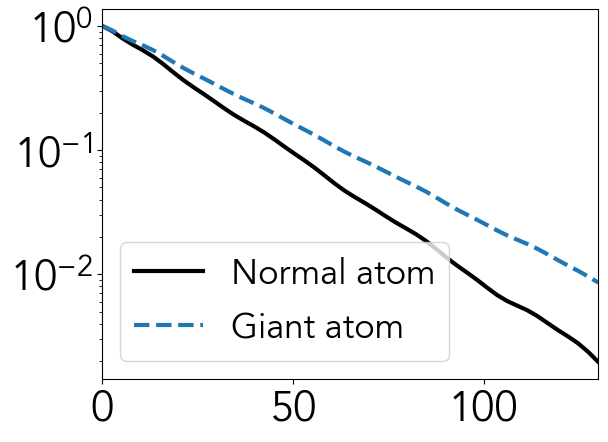

In [ ]:
lw = 3

plt.plot(t, pe, color="black", label="Normal atom", lw=lw)
plt.plot(t, pe_giant, linestyle="--", label="Giant atom", lw=lw)

plt.xlim(0, 130)

plt.yticks([0., 0.5, 1.])
plt.yscale("log")
plt.legend()

plt.savefig(PATH + "atomic_population_normal_and_giant.pdf", bbox_inches="tight")

# Figure 4

<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_31050/2805902362.py:29: SyntaxWarning: invalid escape sequence '\d'
  """


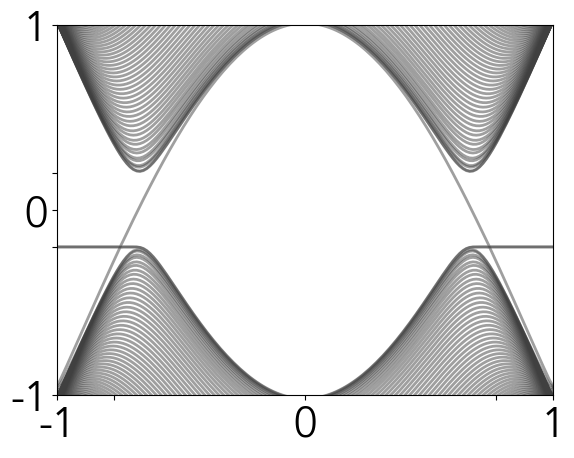

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

def compute_positions_along_direction_a1(lattice):
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)
  
  na_line = []
  nb_line = []

  n = 0.
  for mm in m:
    ra = mm * a1

    na_line.append(ra)

    rb = mm * a1 + d1
    nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


def compute_positions_along_line(lattice):
  """
    Computes real lattice positions for sites that lie n a line at y = 0. The
    positions that fullfil such a thing are giving by

    $R_a = n a_1 + m a_2$, such that $n = -2m$ and
    $R_b = n a_1 + m a_2 + \delta$, such that $n =1 -2m$
  """
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)

  na_line = []
  nb_line = []

  for mm in m:
    n = - 2 * mm
    if n in m:
      ra = n * a1 + mm * a2
      na_line.append(ra)
  
    n = 1 - 2 * mm
    if n in m:
      rb = n * a1 + mm * a2 + d1
      nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


# def Hrm(diagonal, v, w, N):
#     """Open-boundary Rice-Mele Hamiltonian with N unit cells (2N sites).
#     eps0 is the full sublattice energy gap (onsites = +/- eps0/2)."""
#     # diagonal[0] = 1e5
#     # diagonal[-1] = 1e5
#     H  = np.diag(diagonal/2)
#     H += np.diag([v]*N,          k=N)       # intracell bonds
#     H += np.diag([0]+[w]*(N-1)+[0], k=N-1)  # intercell bonds
#     return H + H.T

def Hrm(diag_a, diag_b, v, w, N):
    # Diagonal blocks
    DA = np.diag(diag_a)
    DB = np.diag(diag_b)

    # Off-diagonal block (A → B)
    T = np.zeros((N, N))

    # intracell
    for i in range(N):
        T[i, i] = v

    # intercell
    for i in range(N-1):
        T[i+1, i] = w

    # Full Hamiltonian
    H = np.block([
        [DA,          T],
        [T.conj().T, DB]
    ])

    return H


def spectrum_vs_k(N_cells, lattice, Nk=400):
    """Return k grid and array of shape (Nk, 2N) with eigenvalues."""
    k_vals = np.linspace(-np.pi, np.pi, Nk)
    na, nb = compute_positions_along_direction_a1(lattice)

    # The number of a sites should give the number of unit cells for the 
    # Rice Mele
    N_cells = na.shape[1]

    spec   = np.empty((Nk, 2*N_cells))
    states = np.empty((Nk, 2*N_cells, 2*N_cells), dtype=float)  # real H → real vecs



    diag_a = lattice.delta_0 * np.tanh(na[0]/lattice.lambd)
    diag_b = -lattice.delta_0 * np.tanh(nb[0]/lattice.lambd)
    # diagonal = np.hstack([diag_a, diag_b])

    # diag_a[0] = 1e3
    # diag_b[-1] = 1e3
    for i, k in enumerate(k_vals):
        v = 2*lattice.J*np.cos(k/2)
        w = lattice.J                 # k-dependent intercell hopping
        H = Hrm(diag_a, diag_b, v, w, N_cells)              # pass 2*delta because Hrm uses eps0/2
        spec[i], states[i] = eigh(H)
    return k_vals, spec, states


N     = 100     # Number of sites for each sublattice
Nk    = 150     # k-resolution
LAMBDA = 4
DELTA = 0.2

latt = Graphene(nmax=N, delta_0=DELTA, lambda_0=LAMBDA, pbc="y")

na, nb = latt.n_real_pos

k1, spectrum, states = spectrum_vs_k(N, latt, Nk=Nk)

fig, ax = plt.subplots()
ax.plot(k1 /np.pi, spectrum, color='0.25', lw=2, alpha=0.5, ms=0.8, rasterized=True)
ax.set_xlim(-1,1)
ax.set_xticks([-1, K6[1]/np.pi , 0, K5[1]/np.pi, 1])
ax.set_yticks([-1, -DELTA , 0, DELTA, 1])
ax.set_xticklabels([-1, None, 0, None, 1])
ax.set_yticklabels([-1, None, 0, None, 1])

ax.set_ylim(-1, 1) 

# ax.axhline(-DELTA, linestyle='dashed', color='red')
# ax.set_xlabel('$k_y$')
# ax.set_ylabel('Spectrum')


fig.savefig(PATH + "spectrum_nanoribbon.pdf", bbox_inches="tight")
plt.show()

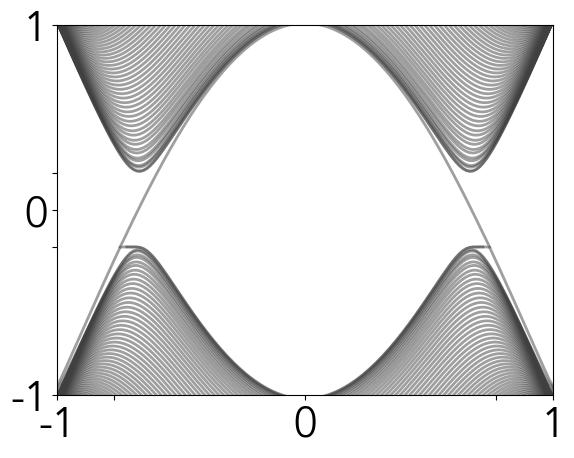

In [8]:
threshold = 1e-9 # tune this to your needs

masked_spectrum = np.ma.masked_where(
    np.abs(spectrum + DELTA) < threshold,
    spectrum
)
fig, ax = plt.subplots()

ax.plot(k1 / np.pi, masked_spectrum, color='0.25', lw=2, alpha=0.5, ms=0.8, rasterized=True)
ax.set_xlim(-1,1)
ax.set_xticks([-1, K6[1]/np.pi , 0, K5[1]/np.pi, 1])
ax.set_yticks([-1, -DELTA , 0, DELTA, 1])
ax.set_xticklabels([-1, None, 0, None, 1])
ax.set_yticklabels([-1, None, 0, None, 1])

ax.set_ylim(-1, 1) 
fig.savefig(PATH + "spectrum_nanoribbon.pdf", bbox_inches="tight")


The energies are:
[-0.16374267 -0.12581432 -0.08824712 -0.0510595  -0.01426953  0.02210506
  0.05804688  0.09353884  0.12856417  0.16310639  0.19714934  0.19714934
  0.16310639  0.12856417  0.09353884  0.05804688  0.02210506 -0.01426953
 -0.0510595  -0.08824712 -0.12581432 -0.16374267]. 
The k's are:
[-2.29821208 -2.25604305 -2.21387402 -2.17170499 -2.12953596 -2.08736693
 -2.0451979  -2.00302887 -1.96085984 -1.91869082 -1.87652179  1.87652179
  1.91869082  1.96085984  2.00302887  2.0451979   2.08736693  2.12953596
  2.17170499  2.21387402  2.25604305  2.29821208]
We are choosing the state with the energy = -0.1637 and k=-0.7315


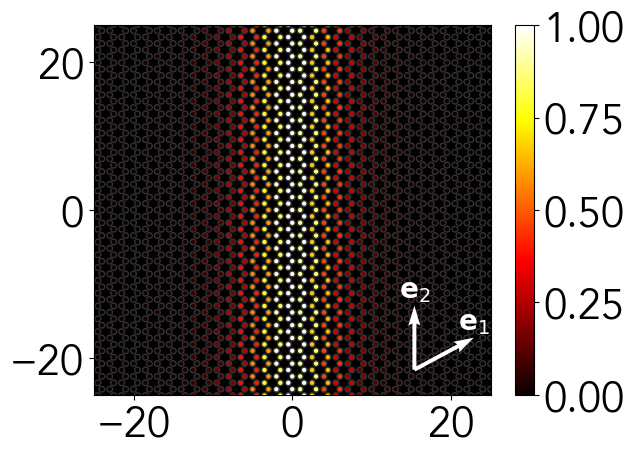

In [418]:
# idxs = np.where(np.isclose(spectrum , 0, atol=1e-1))

idxs = np.where(np.abs(spectrum) < DELTA - 1e-5)

energies = spectrum[idxs]
ks = k1[idxs[0]]

print(f"The energies are:\n{energies}. \nThe k's are:\n{ks}")

i = 0

print(f"We are choosing the state with the energy = {energies[i]:.4f} and k={ks[i] / np.pi:.4f}")

state = states[idxs[0], :, idxs[1]][i]

N = len(state)
psi_a_rm = state[:(N//2)]
psi_b_rm = state[(N//2):]

psi_a_graphene = np.zeros((N//2, N//2))
psi_b_graphene = np.zeros((N//2, N//2))

psi_a_graphene[:] = psi_a_rm
psi_b_graphene[:] = psi_b_rm

psi_a_graphene = psi_a_graphene.flatten()
psi_b_graphene = psi_b_graphene.flatten()

# psi_a_graphene = np.tile(psi_a_rm, (1, 2*N))
# psi_b_graphene = np.tile(psi_b_rm, (1, 2*N))


na, nb = latt.n_real_pos
Cna = np.abs(psi_a_graphene) ** 2
Cnb = np.abs(psi_b_graphene) ** 2

Cna /= Cna.max()
Cnb /= Cnb.max()

fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, s=17, logscale=False, edgecolors="0.2")
cbar = plt.colorbar(im)
# cbar.formatter = ticker.ScalarFormatter(useMathText=True)
# cbar.formatter.set_scientific(True)
# cbar.formatter.set_powerlimits((0, 0))  # Force scientific notation always
# cbar.update_ticks()

# offset = cbar.ax.yaxis.get_offset_text()
# offset.set_visible(False)  # Hide the original

# # Add a centered label manually
# cbar.ax.text(
#     1.9, 1.07,          # x=centered, y=just above the colorbar
#     r'$\times 10^{-3}$',
#     transform=cbar.ax.transAxes,
#     ha='center', va='bottom',
#     fontsize=25
# )
draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.6, 0.43), fontsize=20, scale=(5,5), width=0.01)

ax.set_ylim(-25, 25)
ax.set_xlim(-25, 25)
ax.set_facecolor("black")
# ax.axvline(10, color="white")
# ax.axvline(-10, color="white")
plt.savefig(PATH + "lattice_normal_mode.pdf", bbox_inches="tight")
# ax.set_ylabel("y")
# ax.set_xlabel("x")

## Filtering Flatband states

## Comparing the analytical eigenstate with the numeric

In [306]:
def join_arrays_interchange(x1, x2):
    return np.stack([x1, x2], axis=0).T.flatten()

The energies are: [-0.08824712 -0.0510595  -0.01426953  0.02210506  0.05804688  0.09353884
  0.09353884  0.05804688  0.02210506 -0.01426953 -0.0510595  -0.08824712]. 
The k's are: [-2.21387402 -2.17170499 -2.12953596 -2.08736693 -2.0451979  -2.00302887
  2.00302887  2.0451979   2.08736693  2.12953596  2.17170499  2.21387402]
We are choosing the state with the energy = -0.0882 and k=-2.2139


(0.0, 0.0005)

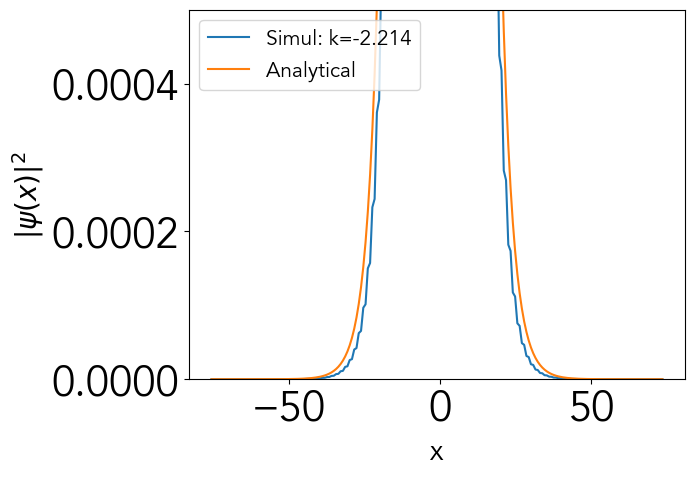

In [308]:
vf = 3/2
idxs = np.where(np.isclose(spectrum , 0, atol=1e-1))

energies = spectrum[idxs]
ks = k1[idxs[0]]

print(f"The energies are: {energies}. \nThe k's are: {ks}")

i = 0

print(f"We are choosing the state with the energy = {energies[i]:.4f} and k={ks[i]:.4f}")

state = states[idxs[0], :, idxs[1]][i]
nn = len(state)

xmin = min(na[0].min(), nb[0].min())
xmax = max(na[0].max(), nb[0].max())
x = np.linspace(xmin, xmax, len(state))

psi = join_arrays_interchange(state[:nn//2], state[nn//2:])
plt.plot(x, np.abs(psi) ** 2, label=f"Simul: k={ks[0]:.3f}")


beta = DELTA * LAMBDA / vf

# NN2  = gamma(beta + 1/2) / gamma(beta) / LAMBDA / np.sqrt(np.pi) 
y = (1/np.cosh(x/LAMBDA)) ** (beta)

NN = np.linalg.norm(y)

y /= NN

plt.plot(x,np.abs(y)**2, label="Analytical")

# plt.plot(np.abs(states[idxs][1]) ** 2, linestyle="dashed", label=f"k={ks[1]:.3f}")
plt.legend(fontsize=15)

plt.xlabel("x")
plt.ylabel(r"$|\psi(x)|^2$")


plt.ylim(0, 0.0005)
# plt.yscale("log")
# plt.xscale("log")

In [246]:
NN

np.float64(4.0066601909560005)

In [250]:
NN

np.float64(4.004976400541678)

In [211]:
np.linalg.norm(psi)

np.float64(1.0000000000000002)

In [228]:
np.linalg.norm(y)

np.float64(1.0)

In [229]:
y = (1/np.cosh(x/LAMBDA)) ** (beta)

In [ ]:
psi = states[idxs][0]
m = psi.shape

(100,)

In [470]:
latt.la

10000

The flatband lies in $\omega = 0.2$

In [13]:
spectrum.shape

(100, 100)

In [ ]:
lat

The energy for this state is omega = 0.058574


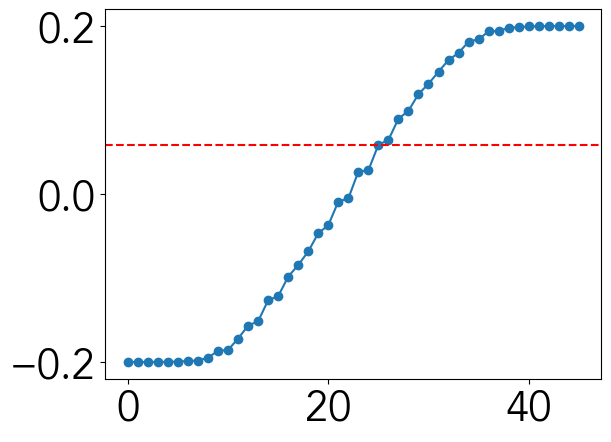

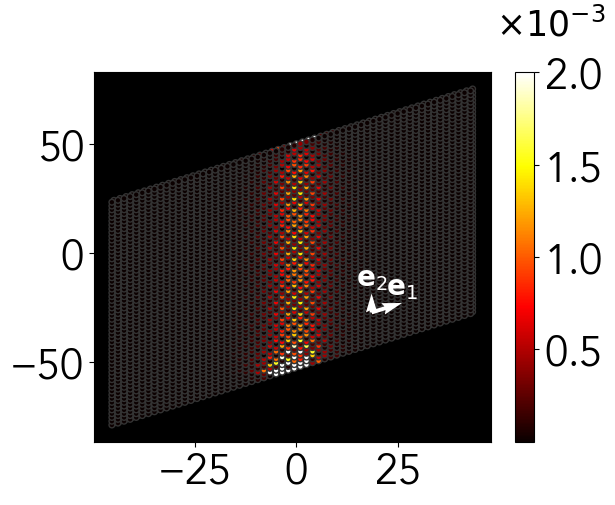

In [378]:
idx = np.where(eigval > 0)[0][1]
i = idx +1
psi = np.asarray(eigvec[:, i]).flatten()
omega = eigval[i]

gap_vals = eigval[np.abs(eigval) <= DELTA]
plt.plot(gap_vals, "-o")
plt.axhline(omega, color='red', linestyle='dashed')
# plt.ylim(-0.2, 0.2)

print(f"The energy for this state is omega = {omega:.5}")

psi_a = psi[:latt.la]
psi_b = psi[latt.la:]

na, nb = latt.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2

fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, s=17, logscale=False, vmax=0.002, edgecolors="0.2")
cbar = plt.colorbar(im)
cbar.formatter = ticker.ScalarFormatter(useMathText=True)
cbar.formatter.set_scientific(True)
cbar.formatter.set_powerlimits((0, 0))  # Force scientific notation always
cbar.update_ticks()

offset = cbar.ax.yaxis.get_offset_text()
offset.set_visible(False)  # Hide the original

# Add a centered label manually
cbar.ax.text(
    1.9, 1.07,          # x=centered, y=just above the colorbar
    r'$\times 10^{-3}$',
    transform=cbar.ax.transAxes,
    ha='center', va='bottom',
    fontsize=25
)
draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.35), fontsize=20, scale=(5,5), width=0.01)

# ax.set_ylim(-25, 25)
# ax.set_xlim(-25, 25)
ax.set_facecolor("black")
# ax.axvline(10, color="white")
# ax.axvline(-10, color="white")
# plt.savefig(PATH + "lattice_normal_mode.pdf", bbox_inches="tight")
# ax.set_ylabel("y")
# ax.set_xlabel("x")

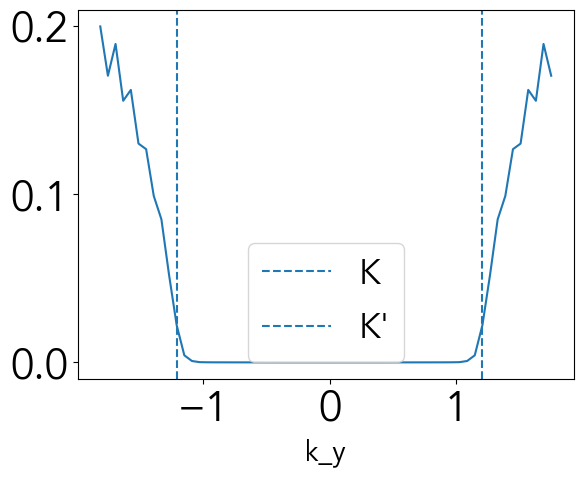

In [372]:
idx = np.where(eigval > 0)[0][0]
i = idx + 1
psi = np.asarray(eigvec[:, i]).flatten()

psi_a = psi[:latt.la]
psi_b = psi[latt.la:]

psi_a_grid = psi_a.reshape(NMAX, NMAX)
psi_b_grid = psi_b.reshape(NMAX, NMAX)

psi_y = psi_a_grid.sum(axis=0)
a_y = np.sqrt(3)
psi_k = np.fft.fftshift(np.fft.fft(psi_y))
ky    = np.fft.fftshift(np.fft.fftfreq(NMAX, d=a_y)) * 2*np.pi

plt.plot(ky, np.abs(psi_k)**2)
plt.axvline( 2*np.pi/(3* np.sqrt(3) * a), ls='--', label='K')
plt.axvline(-2*np.pi/(3* np.sqrt(3) * a), ls='--', label="K'")
plt.xlabel('k_y'); plt.legend(); plt.show()

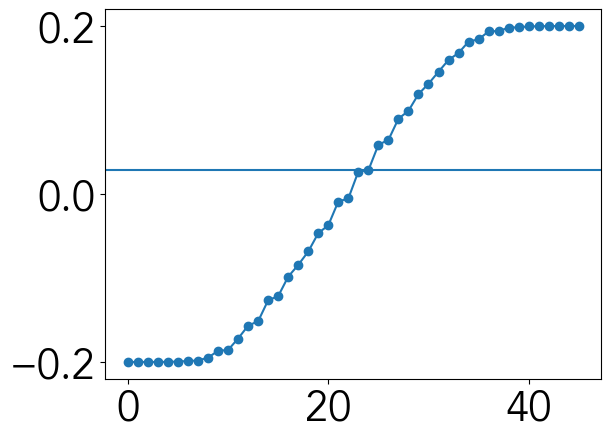

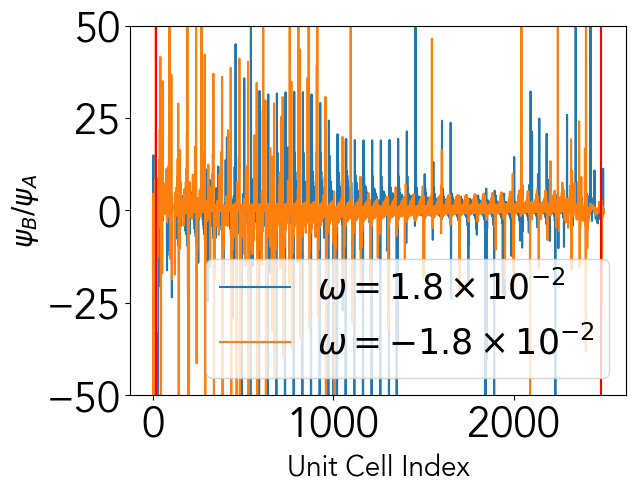

In [245]:
i = idx -1
psi1 = np.asarray(eigvec[:, i]).flatten()
psi1_a = psi1[:latt.la]
psi1_b = psi1[latt.la:]


i = idx + 1
psi2 = np.asarray(eigvec[:, i]).flatten()
psi2_a = psi2[:latt.la]
psi2_b = psi2[latt.la:]

idx_a, idx_b = get_indices_in_range(na,nb, x_range=(-10, 10))


plt.plot(psi1_b/psi1_a, label=r"$\omega = 1.8 \times 10^{-2}$")
plt.plot(psi2_b/psi2_a, label=r"$\omega = -1.8 \times 10^{-2}$")

plt.ylim(-50, 50)

plt.xlabel("Unit Cell Index")
plt.ylabel(r"$\psi_B/ \psi_A$")

plt.legend()
plt.axvline(min(idx_a), color='red')
plt.axvline(max(idx_a), color="red")

In [165]:
def get_indices_in_range(na, nb, x_range=None, y_range=None, r_cutoff=None):
    """
    Extract indices of lattice sites within a specified range.

    Parameters
    ----------
    na, nb    : (2, N) arrays of sublattice A and B positions
    x_range   : tuple (xmin, xmax), optional — keep sites where xmin < x < xmax
    y_range   : tuple (ymin, ymax), optional — keep sites where ymin < y < ymax
    r_cutoff  : float, optional — keep sites where r < r_cutoff (circular region)
                Can be combined with x_range and/or y_range.

    Returns
    -------
    idx_a, idx_b : integer index arrays into na, nb
    """
    mask_a = np.ones(na.shape[1], dtype=bool)
    mask_b = np.ones(nb.shape[1], dtype=bool)

    if x_range is not None:
        xmin, xmax = x_range
        mask_a &= (na[0] >= xmin) & (na[0] <= xmax)
        mask_b &= (nb[0] >= xmin) & (nb[0] <= xmax)

    if y_range is not None:
        ymin, ymax = y_range
        mask_a &= (na[1] >= ymin) & (na[1] <= ymax)
        mask_b &= (nb[1] >= ymin) & (nb[1] <= ymax)

    if r_cutoff is not None:
        ra = np.sqrt(na[0]**2 + na[1]**2)
        rb = np.sqrt(nb[0]**2 + nb[1]**2)
        mask_a &= (ra <= r_cutoff)
        mask_b &= (rb <= r_cutoff)

    return np.where(mask_a)[0], np.where(mask_b)[0]

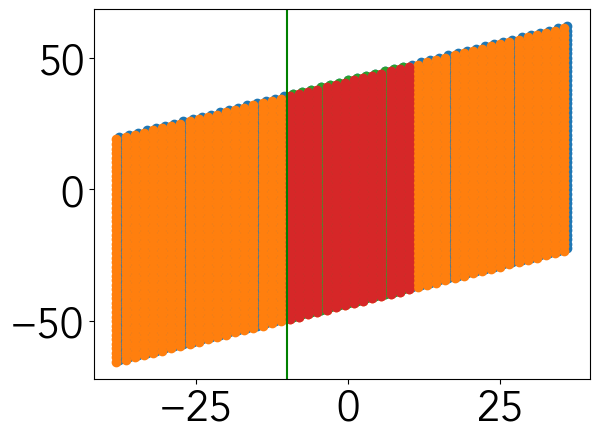

In [174]:
idx_a, idx_b = get_indices_in_range(na,nb, x_range=(-10, 10))


plt.scatter(na[0], na[1])
plt.scatter(nb[0], nb[1])

f_na = na[:,idx_a]
f_nb = nb[:,idx_b]

plt.scatter(f_na[0], f_na[1])
plt.scatter(f_nb[0], f_nb[1])

# plt.xlim(-20, 20)
# plt.ylim(-20, 20)

plt.axvline(-10, color="green")

In [179]:
idx_a, idx_b = get_indices_in_range(na,nb, x_range=(-10, 10))
common_idx = np.intersect1d(idx_a, idx_b)
ratio = psi1_b[common_idx]/psi1_a[common_idx]
np.mean(ratio)

np.float64(3.9517186905838417)

In [180]:
idx_a, idx_b = get_indices_in_range(na,nb, x_range=(-10, 10))
common_idx = np.intersect1d(idx_a, idx_b)
ratio = psi2_b[common_idx]/psi2_a[common_idx]
np.mean(ratio)

np.float64(1.3487859321665534)

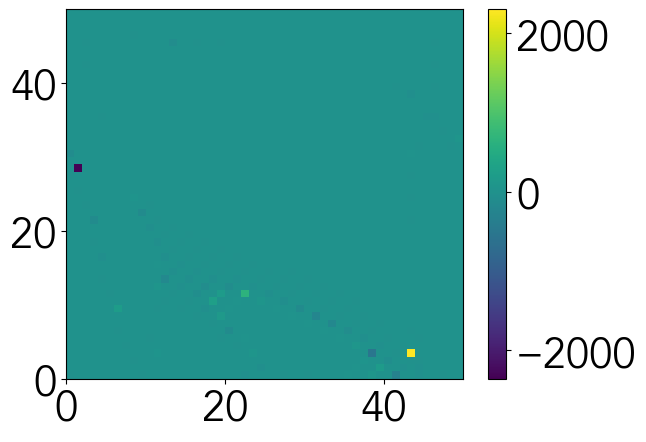

In [159]:
psi_a = psi_a.reshape((N//2, N//2))
psi_b = psi_b.reshape((N//2, N//2))

im = plt.pcolormesh(psi_b/psi_a)

plt.colorbar(im)

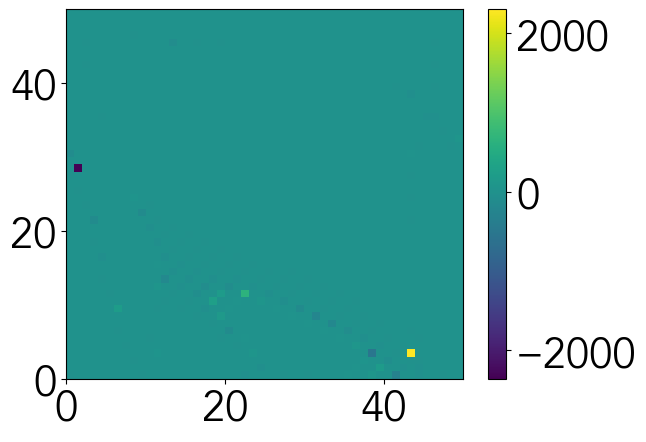

In [132]:
im = plt.pcolormesh(psi_b/psi_a)

plt.colorbar(im)

# Looking for states at the edge of the lattice

The energy for this state is omega = 0.018657


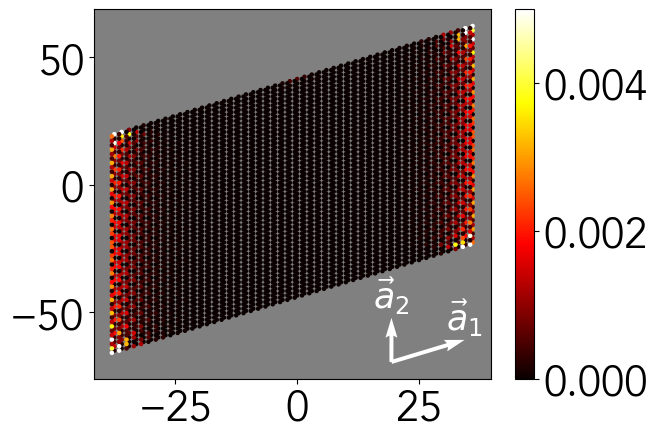

In [282]:
idx = np.where(eigval > 0)[0][1]
psi = np.asarray(eigvec[:, idx-1]).flatten()

print(f"The energy for this state is omega = {eigval[idx]:.5}")

psi_a = psi[:latt.la]
psi_b = psi[latt.la:]

na, nb = latt.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2

fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, vmax=0.005)
plt.colorbar(im)
# ax.set_aspect("equal")
# ax.set_xlim(-45, 45)
draw_basis_vectors(ax, [latt.a1, latt.a2], pos=(0.75, 0.02), fontsize=25, scale=10, width=0.01)

ax.set_facecolor("gray")

# plt.savefig(PATH + "lattice_normal_mode.pdf", bbox_inches="tight")
# ax.set_ylabel("y")
# ax.set_xlabel("x")

According to Francesco, the flatband should contain states that are localized at the edge of the lattice. The following plot find states close to the flatband an plot their shape

Found 9 states close to omega = 0.2
[0.19402594 0.19584186 0.19864298 0.1987929  0.1997022  0.19980117
 0.19994934 0.20000711 0.20001197]


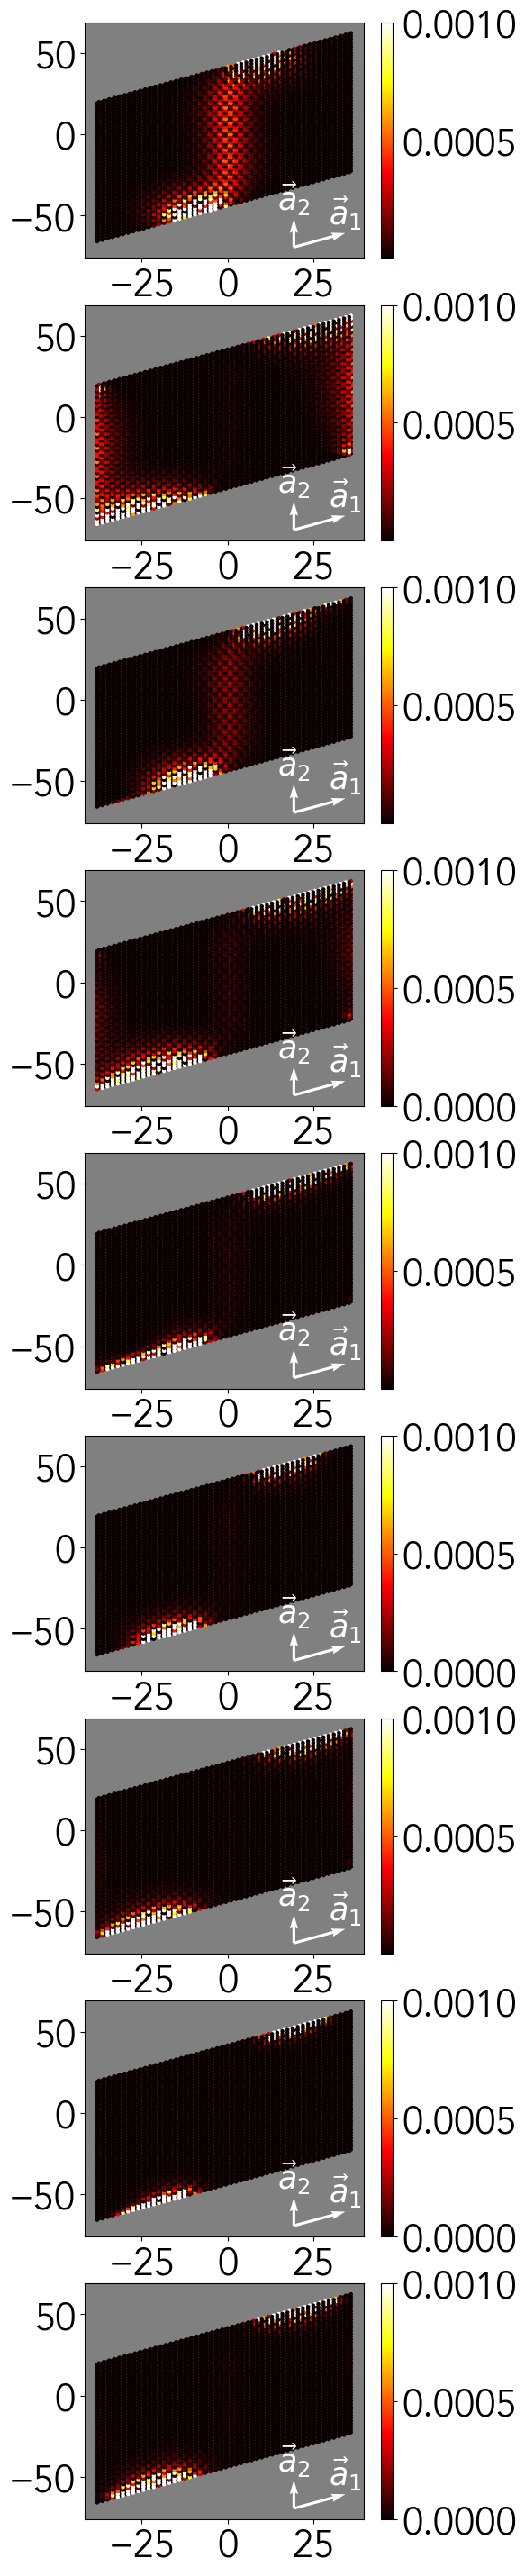

In [280]:
eps = 1e-2
vmax = 1e-3

idxs = np.where(np.isclose(eigval, DELTA, atol=eps))[0]
num_states = len(idxs)

print(f"Found {num_states} states close to omega = {DELTA}")
print(eigval[idxs])
figsize = (5, 4 * num_states)

fig, axs = plt.subplots(nrows=num_states, figsize=figsize)

for i, idx in enumerate(idxs):
  psi = np.asarray(eigvec[:, idx-1]).flatten()
  psi_a = psi[:latt.la]
  psi_b = psi[latt.la:]

  na, nb = latt.n_real_pos
  Cna = np.abs(psi_a) ** 2
  Cnb = np.abs(psi_b) ** 2

  im = plot_graphene(na, nb, Cna, Cnb, axs[i], vmax=vmax)
  plt.colorbar(im)
  draw_basis_vectors(axs[i], [latt.a1, latt.a2], pos=(0.75, 0.02), fontsize=25, scale=10, width=0.01)

  axs[i].set_facecolor("gray")

In [263]:
idx = np.where(np.isclose(eigval, DELTA, atol=1e-4))[0]

psi = np.asarray(eigvec[:, idx-1]).flatten()

print(f"The energy for this state is omega = {eigval[idx]:.5}")

psi_a = psi[:latt.la]
psi_b = psi[latt.la:]

na, nb = latt.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2

fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, vmax=1e-4)
plt.colorbar(im)
# ax.set_aspect("equal")
# ax.set_xlim(-45, 45)
draw_basis_vectors(ax, [latt.a1, latt.a2], pos=(0.75, 0.02), fontsize=25, scale=10, width=0.01)

ax.set_facecolor("gray")

# plt.savefig(PATH + "lattice_normal_mode.pdf", bbox_inches="tight")
# ax.set_ylabel("y")
# ax.set_xlabel("x")

TypeError: unsupported format string passed to numpy.ndarray.__format__

# Figure 5

In [383]:
NMAX = 551
delta = 0.5
lambda_0 = 2
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.3
atom_pos = (0,0)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



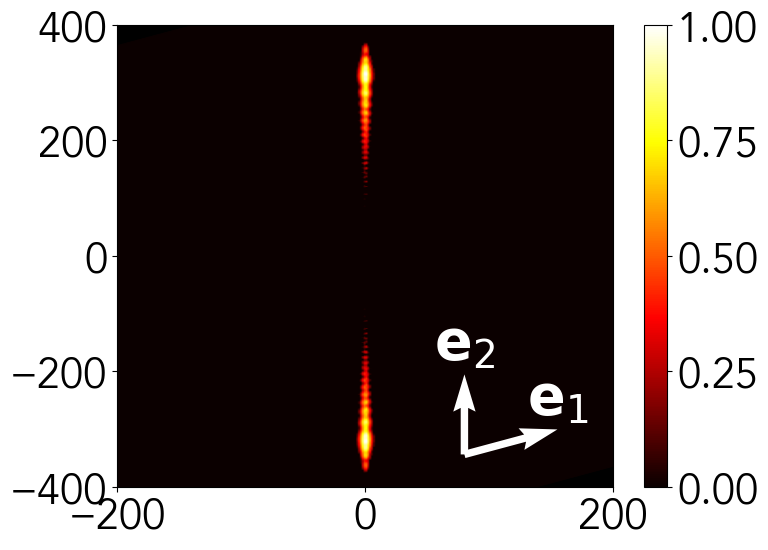

In [385]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


## Checking the decay rate

In [301]:
vf = 3/2
beta = delta * lambda_0/vf
# decay_rate = (G ** 2 ) / (vf * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2)

a1, a2 = lattice.a1, lattice.a2

r0 = atom_pos[0] * a1 + atom_pos[1] * a2
x0 = r0[0]

NN = np.sqrt(gamma(beta + 1/2) / gamma(beta) / lambda_0 / np.sqrt(np.pi))
psi_x0 = NN * (1/np.cosh(x0/lambda_0)) ** beta

A_cell = 3 * np.sqrt(3)/2


# decay_rate =  (G ** 2) * A_cell * np.abs(psi_x0) **2 / vf

decay_rate = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf

print(f"The decay rate is Gamma = {decay_rate}")

The decay rate is Gamma = 0.00864596876899148


In [302]:
# Decay rate semi-numerical
vf = 3/2

a1, a2 = lattice.a1, lattice.a2
na, nb = compute_positions_along_direction_a1(lattice)
beta = delta * lambda_0 / vf

psi_x = (1/np.cosh(na[0]/lambda_0)) ** (beta)

A = np.linalg.norm(psi_x)

A_cell = 3 * np.sqrt(3)/2


r0 = atom_pos[0] * a1 + atom_pos[1] * a2
x0 = r0[0]

psi_x0 = ((1/np.cosh(x0/lambda_0)) ** beta) /A

decay_semi_num = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf

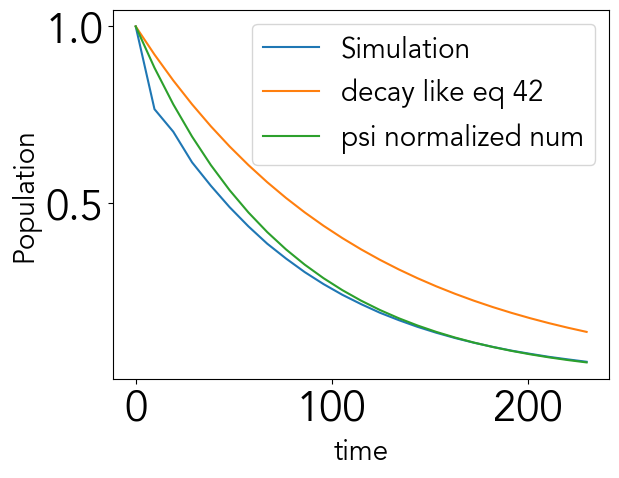

In [303]:
plt.plot(t, pe, label="Simulation")
plt.plot(t, np.exp(-t * decay_rate), label='decay like eq 42')
plt.plot(t, np.exp(-t * decay_semi_num), label='psi normalized num')

# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend(fontsize=20)

In [43]:
NMAX = 551
delta = 0.5
lambda_0 = 2
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.3
atom_pos = (0,0)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=45)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



In [44]:
vf = 3/2
beta = 2 * delta * lambda_0/vf
# decay_rate = (G ** 2 ) / (vf * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2)

decay_rate =  (G ** 2) / (lambda_0 * vf * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2) * (3 * np.sqrt(3)/2)

beta = delta * lambda_0 / vf
norm = np.sqrt(gamma(beta + 1/2)/gamma(beta) / (lambda_0 * np.sqrt(np.pi)))
decay_rate_francesco = (G **2 ) * np.sqrt(3)  * (norm ** 2)/vf


print(f"The decay rate is Gamma = {decay_rate}")
print(f"The decay rate francesco is Gamma = {decay_rate_francesco}")

The decay rate is Gamma = 0.0301271687789688
The decay rate francesco is Gamma = 0.0200847791859792


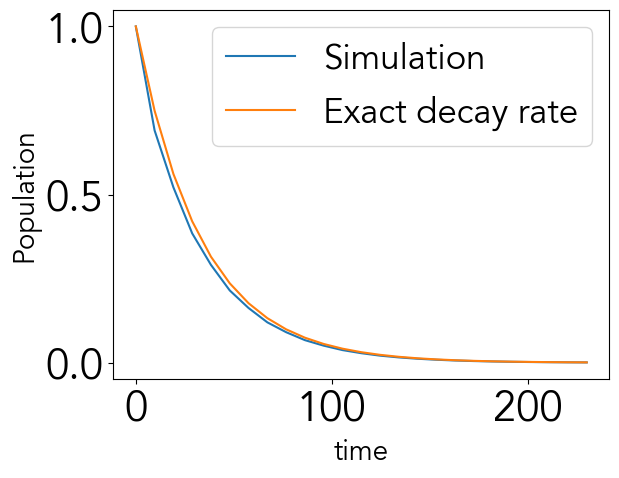

In [45]:
plt.plot(t, pe, label="Simulation")
plt.plot(t, np.exp(-t * decay_rate), label='Exact decay rate')
# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend()

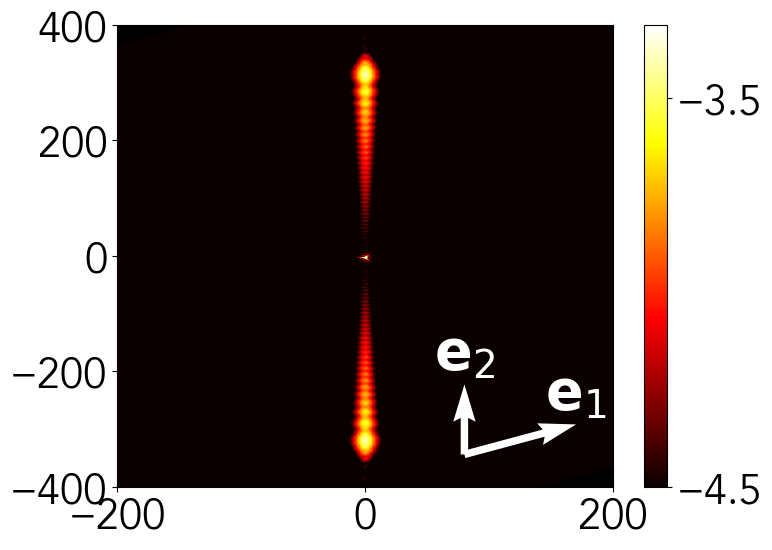

In [310]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=ax, ticks=[-4.5, -3.5, -2.5])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(60, 70), width=0.015)
plt.show()

fig.tight_layout()
# fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


In [413]:
NMAX = 551
delta = 0.5
lambda_0 = 2
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.3
atom_pos = (0,0)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=30)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



The decay rate is Gamma = 0.0301271687789688
The decay rate francesco is Gamma = 0.0200847791859792


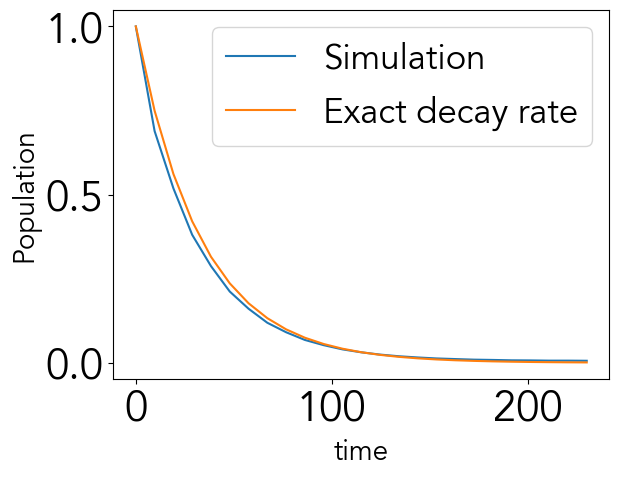

In [415]:
vf = 3/2
beta = 2 * delta * lambda_0/vf
# decay_rate = (G ** 2 ) / (vf * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2)

decay_rate =  (G ** 2) / (lambda_0 * vf * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2) * (3 * np.sqrt(3)/2)

beta = delta * lambda_0 / vf
norm = np.sqrt(gamma(beta + 1/2)/gamma(beta) / (lambda_0 * np.sqrt(np.pi)))
decay_rate_francesco = (G **2 ) * np.sqrt(3)  * (norm ** 2)/vf


print(f"The decay rate is Gamma = {decay_rate}")
print(f"The decay rate francesco is Gamma = {decay_rate_francesco}")


plt.plot(t, pe, label="Simulation")
plt.plot(t, np.exp(-t * decay_rate), label='Exact decay rate')
# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend()

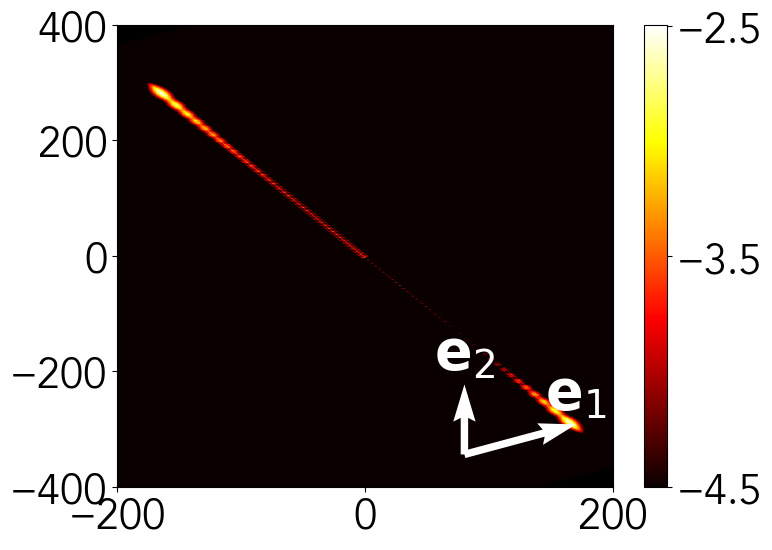

In [416]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=ax, ticks=[-4.5, -3.5, -2.5])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(60, 70), width=0.015)
plt.show()

fig.tight_layout()
# fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


In [226]:
pe[-1] * 100

np.float64(0.08873972174828151)

In [319]:
def compute_position_legs(sys):
    a1 = sys.lattice.a1
    a2 = sys.lattice.a2
    R = []
    for leg in sys.legs:
        pos = leg.pos
        R.append(pos[0] * a1 + pos[1] * a2)
    return R


def compute_phase(r1, r2, tau):
    phi = 1 - 2 * tau / 3 * ((r2[0] - r1[0]) - (r2[1] - r1[1]))
    phi *= np.pi

    return phi

In [103]:
pos1 = (0,0)
pos2 = (0,1)

compute_phase(pos1, pos2, -1)

1.0471975511965979

In [392]:
NMAX = 551
DELTA = 0.5
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.3 / np.sqrt(2)
NUM_POINTS = 25
TF = 200

VALLEY = 1

leg1 = (0,0)
leg2 = (0,1)

print(f"Giant atom placed at \nr1 = {leg1}\nr2 = {leg2}")

PHI = compute_phase(leg1, leg2, VALLEY)

print(f"phi = {PHI}")
# PHI = np.pi/3


sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=leg1),
              Leg(site="A", pos=leg2, phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

Giant atom placed at 
r1 = (0, 0)
r2 = (0, 1)
phi = 5.235987755982988


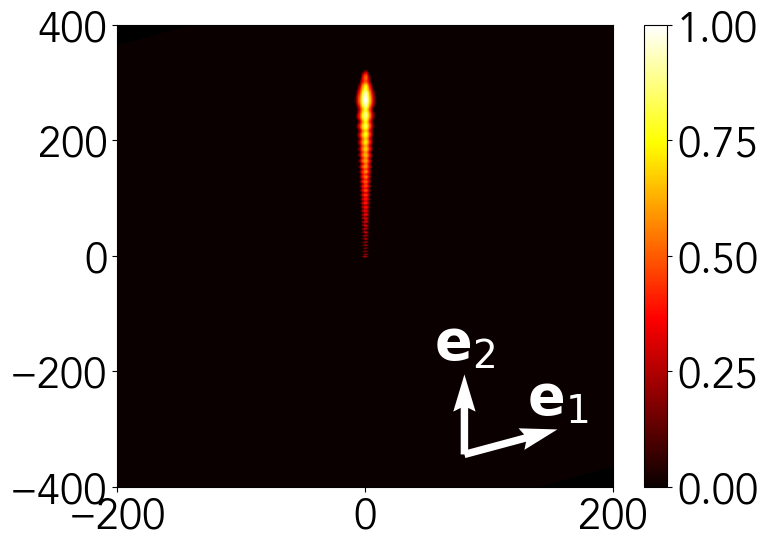

In [393]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_giant_atom_phi=minus_piO3.pdf", bbox_inches="tight")

In [126]:
K = np.array([2 * np.pi / 3, - 2 * np.pi/(3 * np.sqrt(3))])

vf = 3/2
beta = DELTA * lambda_0 / vf

NN = np.sqrt(1/(lambda_0 * np.sqrt(np.pi)) * gamma(beta + 1/2) / gamma(beta))
A_cell = 3 * np.sqrt(3)/2


gl = np.array([G, G * np.exp(1j * PHI)])


R = compute_position_legs(sys)
x0 = R[0][0]

psi_x = NN * (1/np.cosh(x0/lambda_0)) ** (beta)

gamma_normal_valley = (G ** 2) * A_cell * np.abs(psi_x) ** 2 / vf
gamma_giant = 0


for tau in [-1, 1]:
  arg = PHI + tau * K @ (R[1] - R[0]) + tau * OMEGA_0 * (R[1][1] - R[0][1])/vf
  modulus = 1 + np.exp(1j * arg)

  gamma_giant += 0.5 * np.abs(modulus) ** 2 * gamma_normal_valley


print(f"The decay rate is Gamma = {gamma_giant}")

The decay rate is Gamma = 0.0007377483154259467


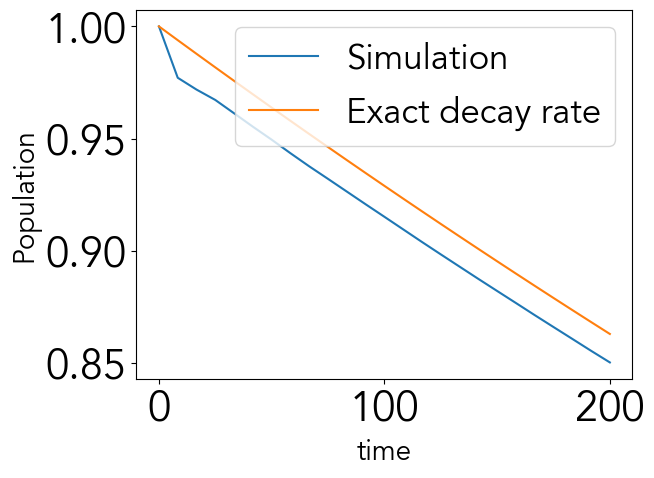

In [127]:
plt.plot(t, pe, label="Simulation")
plt.plot(t, np.exp(-t * gamma_giant), label='Exact decay rate')
plt.xlabel("time")
plt.ylabel("Population")
# plt.ylim(0, 1.05)
# plt.yticks([0, 0.25, 0.5, 0.75, 1.])

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

In [128]:
DELTA

0.1

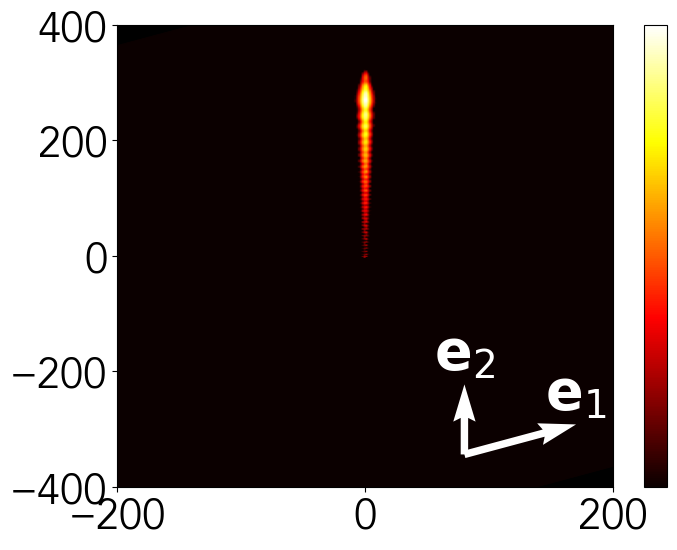

In [ ]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(60, 70), width=0.015)
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_giant_atom_phi=minus_piO3.pdf", bbox_inches="tight")



In [231]:
pe[-1] * 100

np.float64(1.0879017502112853)

In [390]:
NMAX = 551
DELTA = 0.5
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.3 / np.sqrt(2)
NUM_POINTS = 25
TF = 200

PHI = np.pi/3

sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

In [233]:
vf = 3/2
betaO2 = DELTA * lambda_0 / vf
alpha = (np.cosh(np.sqrt(3)/(2 * lambda_0))) ** (- betaO2)

gamma_normal = (G**2) / (vf * lambda_0 * np.sqrt(np.pi)) * (3 * np.sqrt(3)/2) * gamma(betaO2 + 1/2) / gamma(betaO2)
gamma_giant = gamma_normal * (1 + alpha ** 2 + 2* alpha * np.cos(PHI) * np.cos(OMEGA_0/J - 2 * np.pi/3))

print(f"The decay rate is Gamma = {gamma_giant}")

The decay rate is Gamma = 0.021318072438780093


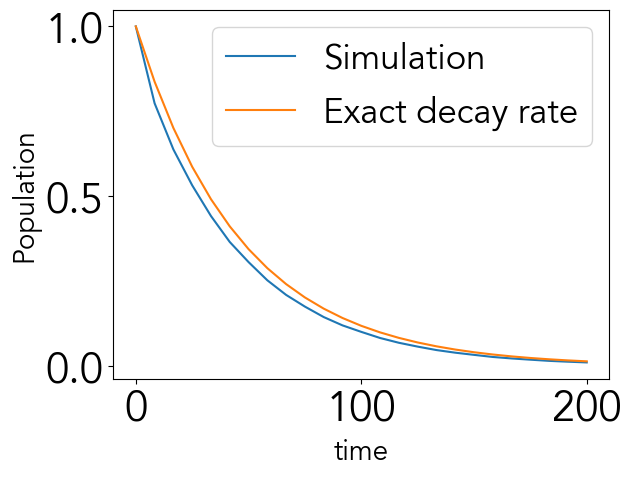

In [234]:
plt.plot(t, pe, label="Simulation")
plt.plot(t, np.exp(-t * gamma_giant), label='Exact decay rate')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend()

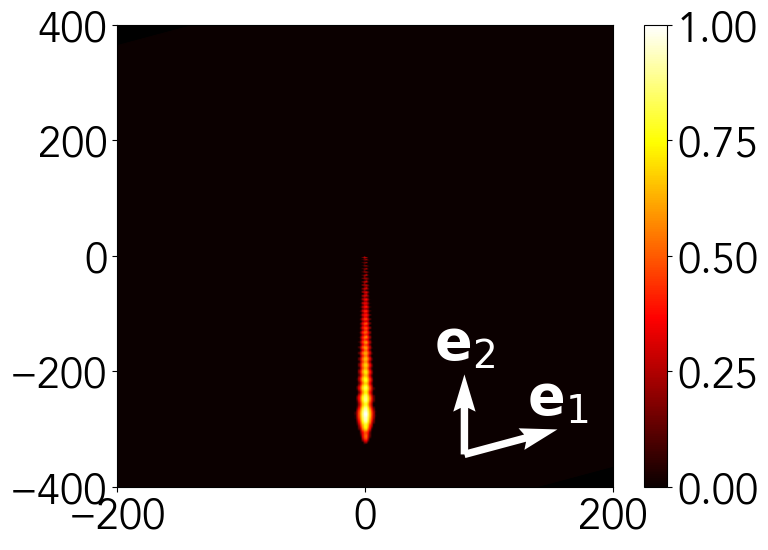

In [391]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_giant_atom_phi=piO3.pdf", bbox_inches="tight")



In [236]:
pe[-1] * 100

np.float64(1.0879017502112858)

# Figure 6

In [421]:
def map_rice_mele_graphene(Nsites):
  psi_a_rm = state[:(Nsites//2)]
  psi_b_rm = state[(Nsites//2):]

  psi_a_graphene = np.zeros((Nsites//2, Nsites//2))
  psi_b_graphene = np.zeros((Nsites//2, Nsites//2))

  psi_a_graphene[:] = psi_a_rm
  psi_b_graphene[:] = psi_b_rm

  psi_a_graphene = psi_a_graphene.flatten()
  psi_b_graphene = psi_b_graphene.flatten()

  return psi_a_graphene, psi_b_graphene

<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_34177/4018183660.py:29: SyntaxWarning: invalid escape sequence '\d'
  """


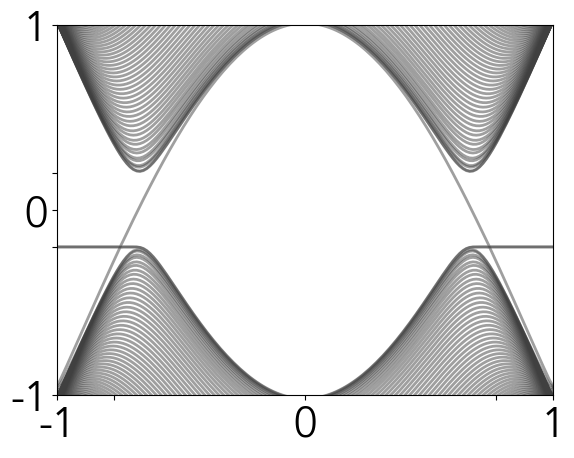

In [420]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

def compute_positions_along_direction_a1(lattice):
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)
  
  na_line = []
  nb_line = []

  n = 0.
  for mm in m:
    ra = mm * a1

    na_line.append(ra)

    rb = mm * a1 + d1
    nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


def compute_positions_along_line(lattice):
  """
    Computes real lattice positions for sites that lie n a line at y = 0. The
    positions that fullfil such a thing are giving by

    $R_a = n a_1 + m a_2$, such that $n = -2m$ and
    $R_b = n a_1 + m a_2 + \delta$, such that $n =1 -2m$
  """
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)

  na_line = []
  nb_line = []

  for mm in m:
    n = - 2 * mm
    if n in m:
      ra = n * a1 + mm * a2
      na_line.append(ra)
  
    n = 1 - 2 * mm
    if n in m:
      rb = n * a1 + mm * a2 + d1
      nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


# def Hrm(diagonal, v, w, N):
#     """Open-boundary Rice-Mele Hamiltonian with N unit cells (2N sites).
#     eps0 is the full sublattice energy gap (onsites = +/- eps0/2)."""
#     # diagonal[0] = 1e5
#     # diagonal[-1] = 1e5
#     H  = np.diag(diagonal/2)
#     H += np.diag([v]*N,          k=N)       # intracell bonds
#     H += np.diag([0]+[w]*(N-1)+[0], k=N-1)  # intercell bonds
#     return H + H.T

def Hrm(diag_a, diag_b, v, w, N):
    # Diagonal blocks
    DA = np.diag(diag_a)
    DB = np.diag(diag_b)

    # Off-diagonal block (A → B)
    T = np.zeros((N, N))

    # intracell
    for i in range(N):
        T[i, i] = v

    # intercell
    for i in range(N-1):
        T[i+1, i] = w

    # Full Hamiltonian
    H = np.block([
        [DA,          T],
        [T.conj().T, DB]
    ])

    return H


def spectrum_vs_k(N_cells, lattice, Nk=400):
    """Return k grid and array of shape (Nk, 2N) with eigenvalues."""
    k_vals = np.linspace(-np.pi, np.pi, Nk)
    na, nb = compute_positions_along_direction_a1(lattice)

    # The number of a sites should give the number of unit cells for the 
    # Rice Mele
    N_cells = na.shape[1]

    spec   = np.empty((Nk, 2*N_cells))
    states = np.empty((Nk, 2*N_cells, 2*N_cells), dtype=float)  # real H → real vecs



    diag_a = lattice.delta_0 * np.tanh(na[0]/lattice.lambd)
    diag_b = -lattice.delta_0 * np.tanh(nb[0]/lattice.lambd)
    # diagonal = np.hstack([diag_a, diag_b])

    # diag_a[0] = 1e3
    # diag_b[-1] = 1e3
    for i, k in enumerate(k_vals):
        v = 2*lattice.J*np.cos(k/2)
        w = lattice.J                 # k-dependent intercell hopping
        H = Hrm(diag_a, diag_b, v, w, N_cells)              # pass 2*delta because Hrm uses eps0/2
        spec[i], states[i] = eigh(H)
    return k_vals, spec, states


N     = 100     # Number of sites for each sublattice
Nk    = 150     # k-resolution
LAMBDA = 4
DELTA = 0.2

latt = Graphene(nmax=N, delta_0=DELTA, lambda_0=LAMBDA, pbc="y")

na, nb = latt.n_real_pos

k1, spectrum, states = spectrum_vs_k(N, latt, Nk=Nk)

fig, ax = plt.subplots()
ax.plot(k1 /np.pi, spectrum, color='0.25', lw=2, alpha=0.5, ms=0.8, rasterized=True)
ax.set_xlim(-1,1)
ax.set_xticks([-1, K6[1]/np.pi , 0, K5[1]/np.pi, 1])
ax.set_yticks([-1, -DELTA , 0, DELTA, 1])
ax.set_xticklabels([-1, None, 0, None, 1])
ax.set_yticklabels([-1, None, 0, None, 1])

ax.set_ylim(-1, 1) 

# ax.axhline(-DELTA, linestyle='dashed', color='red')
# ax.set_xlabel('$k_y$')
# ax.set_ylabel('Spectrum')


# fig.savefig(PATH + "spectrum_nanoribbon.pdf", bbox_inches="tight")
plt.show()

The energies are:
[-0.16374267 -0.12581432 -0.08824712 -0.0510595  -0.01426953  0.02210506
  0.05804688  0.09353884  0.12856417  0.16310639  0.19714934  0.19714934
  0.16310639  0.12856417  0.09353884  0.05804688  0.02210506 -0.01426953
 -0.0510595  -0.08824712 -0.12581432 -0.16374267]. 
The k's are:
[-2.29821208 -2.25604305 -2.21387402 -2.17170499 -2.12953596 -2.08736693
 -2.0451979  -2.00302887 -1.96085984 -1.91869082 -1.87652179  1.87652179
  1.91869082  1.96085984  2.00302887  2.0451979   2.08736693  2.12953596
  2.17170499  2.21387402  2.25604305  2.29821208]
We are choosing the state with the energy = -0.1637 and k=-0.7315


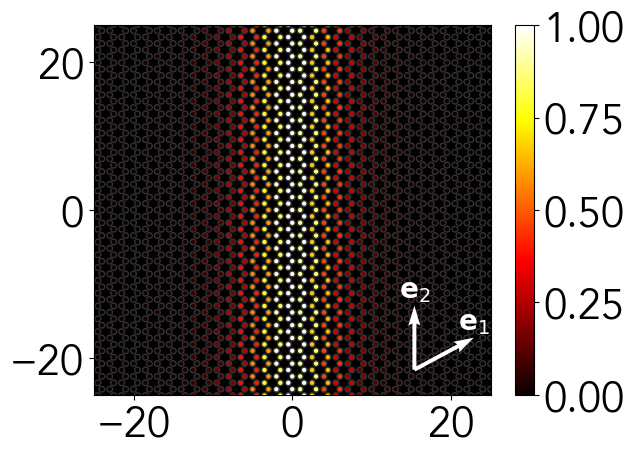

In [422]:
# idxs = np.where(np.isclose(spectrum , 0, atol=1e-1))

idxs = np.where(np.abs(spectrum) < DELTA - 1e-5)

energies = spectrum[idxs]
ks = k1[idxs[0]]

print(f"The energies are:\n{energies}. \nThe k's are:\n{ks}")

i = 0

energy = energies[i]
kc = ks[i]
print(f"We are choosing the state with the energy = {energy:.4f} and k={kc / np.pi:.4f}")

state = states[idxs[0], :, idxs[1]][i]

N = len(state)


psi_a_graphene, psi_b_graphene = map_rice_mele_graphene(N)

na, nb = latt.n_real_pos
Cna = np.abs(psi_a_graphene) ** 2
Cnb = np.abs(psi_b_graphene) ** 2

Cna /= Cna.max()
Cnb /= Cnb.max()

fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, s=17, logscale=False, edgecolors="0.2")
cbar = plt.colorbar(im)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.6, 0.43), fontsize=20, scale=(5,5), width=0.01)

ax.set_ylim(-25, 25)
ax.set_xlim(-25, 25)
ax.set_facecolor("black")
# ax.axvline(10, color="white")
# ax.axvline(-10, color="white")
plt.savefig(PATH + "lattice_normal_mode.pdf", bbox_inches="tight")
# ax.set_ylabel("y")
# ax.set_xlabel("x")

In [423]:
def compute_psi_analytical(delta, lambd, na, nb, Nsites):
  beta = delta * lambd / vf

  xmin = min(na[0].min(), nb[0].min())
  xmax = max(na[0].max(), nb[0].max())
  x = np.linspace(xmin, xmax, Nsites)
  
  psi_x = (1/np.cosh(x/lambd)) ** (beta)

  A = 1/np.sqrt(np.sum((1/np.cosh(x/lambd)) ** (2*beta)))

  psi_x *= A

  return psi_x


The energies are: [-0.08824712 -0.0510595  -0.01426953  0.02210506  0.05804688  0.09353884
  0.09353884  0.05804688  0.02210506 -0.01426953 -0.0510595  -0.08824712]. 
The k's are: [-2.21387402 -2.17170499 -2.12953596 -2.08736693 -2.0451979  -2.00302887
  2.00302887  2.0451979   2.08736693  2.12953596  2.17170499  2.21387402]
We are choosing the state with the energy = -0.0882 and k=-2.2139


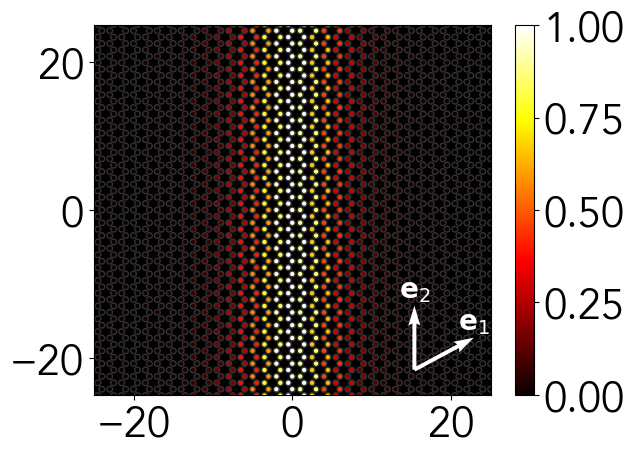

In [424]:
vf = 3/2
idxs = np.where(np.isclose(spectrum , 0, atol=1e-1))

energies = spectrum[idxs]
ks = k1[idxs[0]]

print(f"The energies are: {energies}. \nThe k's are: {ks}")

i = 0

print(f"We are choosing the state with the energy = {energies[i]:.4f} and k={ks[i]:.4f}")

psi_x = compute_psi_analytical(DELTA, LAMBDA, na, nb, len(state))

psi_a_graphene_analytical, psi_b_graphene_analytical = map_rice_mele_graphene(N)

na, nb = latt.n_real_pos
Cna = np.abs(psi_a_graphene_analytical) ** 2
Cnb = np.abs(psi_b_graphene_analytical) ** 2

Cna /= Cna.max()
Cnb /= Cnb.max()

fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, s=17, logscale=False, edgecolors="0.2")
cbar = plt.colorbar(im)

draw_basis_vectors(ax, [latt.a1, latt.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.6, 0.43), fontsize=20, scale=(5,5), width=0.01)

ax.set_ylim(-25, 25)
ax.set_xlim(-25, 25)
ax.set_facecolor("black")

plt.savefig(PATH + "lattice_normal_mode_analytical.pdf", bbox_inches="tight")


# Normalization of the Eigenstate

In [222]:
N = 100
DELTA = 0.5
LAMBDA = 4

latt = Graphene(nmax=N, delta_0=DELTA, lambda_0=LAMBDA, pbc="y")
na, nb = compute_positions_along_direction_a1(latt)

beta = DELTA * LAMBDA / vf

NN2  = gamma(beta + 1/2) / gamma(beta) / LAMBDA / np.sqrt(np.pi) 
psi_a = (1/np.cosh(na[0]/LAMBDA)) ** (beta) * np.sqrt(NN2)
psi_b = (1/np.cosh(nb[0]/LAMBDA)) ** (beta) * np.sqrt(NN2)


np.linalg.norm(psi_a)**2



np.float64(0.6666666680173631)

In [223]:
psi_a.conj() @ psi_a

np.float64(0.6666666680173631)